# Analiza eksploracyjna zbioru Chest X-rays (Indiana University)
źródło: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [10]:
DATASET_PATH = "../datasets/iu/"
CSV_NAME1 = "indiana_projections.csv"
CSV_NAME2 = "indiana_reports.csv"

In [33]:
proj = pd.read_csv(DATASET_PATH+CSV_NAME1, index_col=0)
reports = pd.read_csv(DATASET_PATH+CSV_NAME2, index_col=0)

---

In [34]:
proj.info()

<class 'pandas.DataFrame'>
Index: 7466 entries, 1 to 3999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    7466 non-null   str  
 1   projection  7466 non-null   str  
dtypes: str(2)
memory usage: 175.0 KB


In [18]:
proj.head()

,filename,projection
uid,,
1,1_IM-0001-4001.dcm.png,Frontal
1,1_IM-0001-3001.dcm.png,Lateral
2,2_IM-0652-1001.dcm.png,Frontal
2,2_IM-0652-2001.dcm.png,Lateral
3,3_IM-1384-1001.dcm.png,Frontal


In [37]:
proj.isna().sum()

filename      0
projection    0
dtype: int64

In [29]:
counts = proj.groupby('projection')['filename'].count()
counts

projection
Frontal    3818
Lateral    3648
Name: filename, dtype: int64

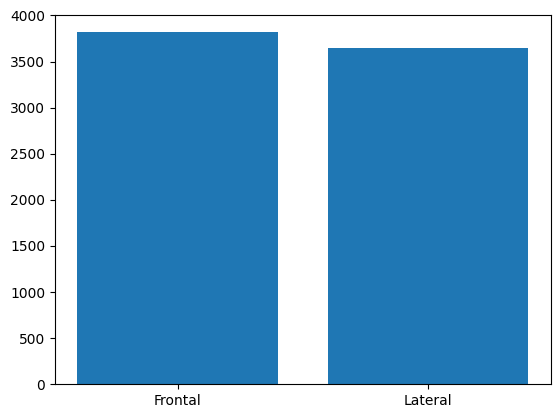

In [30]:
plt.figure(dpi=100)
plt.bar(counts.index, counts.values)
plt.show()

---

In [35]:
reports.info()

<class 'pandas.DataFrame'>
Index: 3851 entries, 1 to 3999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   MeSH        3851 non-null   str  
 1   Problems    3851 non-null   str  
 2   image       3851 non-null   str  
 3   indication  3765 non-null   str  
 4   comparison  2685 non-null   str  
 5   findings    3337 non-null   str  
 6   impression  3820 non-null   str  
dtypes: str(7)
memory usage: 240.7 KB


In [36]:
reports.head()

,MeSH,Problems,image,indication,comparison,findings,impression
uid,,,,,,,
1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [49]:
missing = reports.isna().sum().sort_values()

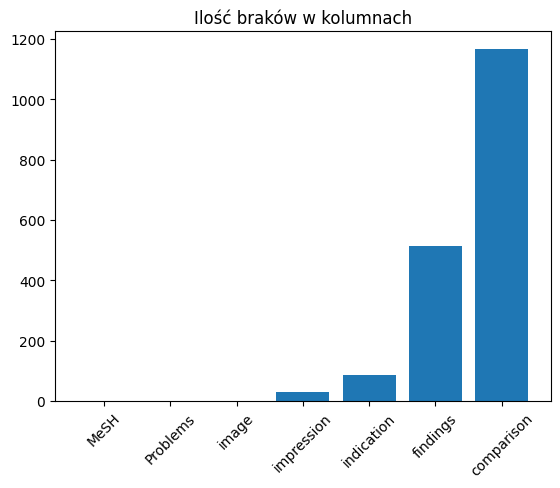

In [50]:
plt.figure(dpi=100)
plt.bar(missing.index,missing.values)
plt.title("Ilość braków w kolumnach")
plt.xticks(rotation=45)
plt.show()

In [74]:
reports.dropna()

,MeSH,Problems,image,indication,comparison,findings,impression
uid,,,,,,,
1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
6,normal,normal,"PA and Lateral Chest. XXXX, XXXX at XXXX",Evaluate for infection,"XXXX, XXXX",Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.
7,Pulmonary Atelectasis/base;Spondylosis/thoraci...,Pulmonary Atelectasis;Spondylosis;Arthritis,Xray Chest PA and Lateral,Preop lumbar surgery,"XXXX, XXXX",The cardiac contours are normal. XXXX basilar ...,Basilar atelectasis. No confluent lobar consol...
...,...,...,...,...,...,...,...
3988,Opacity/lung/lingula/streaky;Opacity/lung/base...,Opacity;Opacity;Diaphragm;Calcified Granuloma,PA and lateral chest radiograph (2 views) (2 i...,"XXXX, rib pain.",None.,"No acute osseous abnormalities. Left midlung, ...",No acute osseous abnormalities. If continued c...
3991,Spondylosis/thoracic vertebrae,Spondylosis,Xray Chest PA and Lateral,Preop bariatric surgery,None.,The cardiac contours are normal. The lungs are...,No acute preoperative findings.
3994,Cardiomegaly/mild;Pulmonary Congestion;Heart F...,Cardiomegaly;Pulmonary Congestion;Heart Failure,2 view ( PA and lateral) chest radiograph date...,"XXXX-year-old male with chest pain, positive t...","Portable chest x-XXXX XXXX, XXXX",Similar mild cardiomegaly. Of the pulmonary va...,Mild cardiomegaly with XXXX of early failure.


In [75]:
categorical_columns = reports.columns

In [76]:
d = {}
for cat in categorical_columns:
    d[cat] = reports[cat].value_counts().to_dict()


MeSH: {'normal': 1379, 'No Indexing': 92, 'Lung/hypoinflation': 44, 'Thoracic Vertebrae/degenerative/mild': 29, 'Thoracic Vertebrae/degenerative': 23}


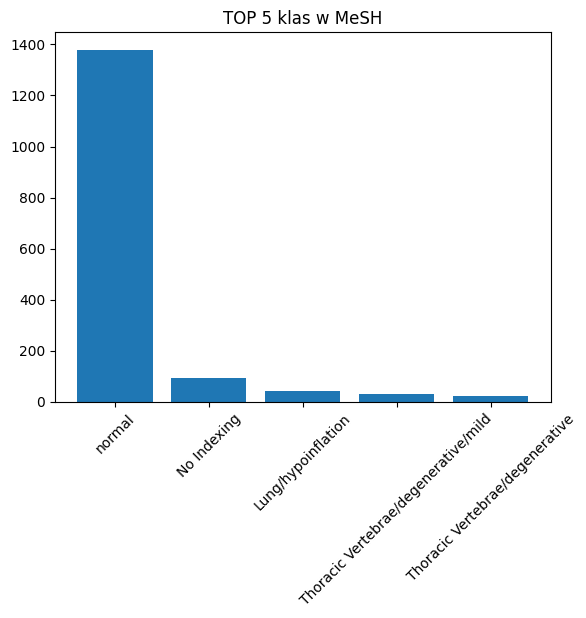

Problems: {'normal': 1379, 'No Indexing': 92, 'Lung': 86, 'Calcified Granuloma': 84, 'Thoracic Vertebrae': 59}


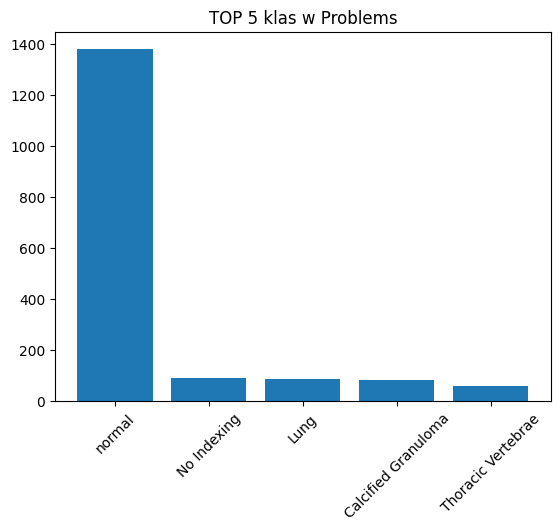

image: {'Xray Chest PA and Lateral': 1218, 'CHEST 2V FRONTAL/LATERAL ': 92, 'Chest, 2 views, frontal and lateral': 63, 'PA and lateral chest x-XXXX XXXX at XXXX hours. ': 52, 'CHEST 2V FRONTAL/LATERAL XXXX, XXXX XXXX PM ': 49}


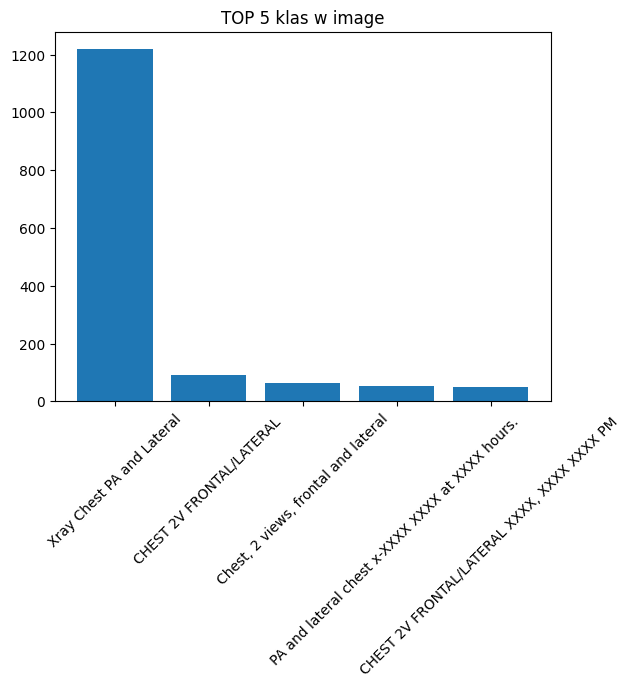

indication: {'Chest pain': 129, 'XXXX': 114, 'Chest pain.': 88, 'chest pain': 62, 'XXXX.': 58}


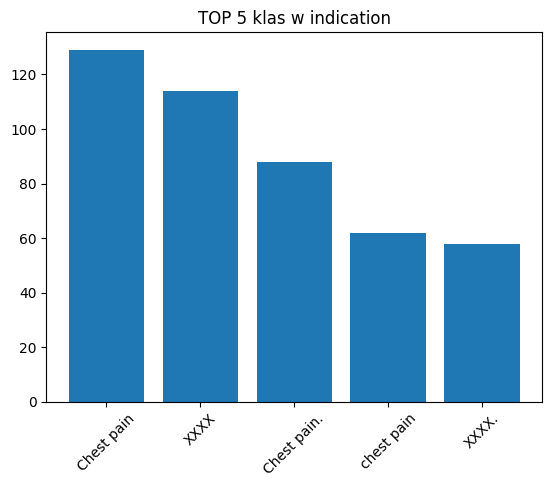

comparison: {'None.': 814, 'XXXX': 280, 'XXXX, XXXX.': 220, 'XXXX, XXXX': 159, 'None available.': 126}


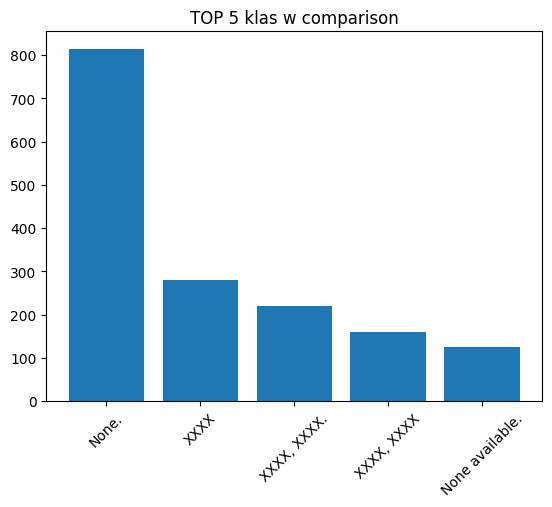

findings: {'The heart and lungs have XXXX XXXX in the interval. Both lungs are clear and expanded. Heart and mediastinum normal.': 51, 'The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.': 51, 'Heart size normal. Lungs are clear. XXXX are normal. No pneumonia, effusions, edema, pneumothorax, adenopathy, nodules or masses.': 46, 'The lungs are clear bilaterally. Specifically, no evidence of focal consolidation, pneumothorax, or pleural effusion.. Cardio mediastinal silhouette is unremarkable. Visualized osseous structures of the thorax are without acute abnormality.': 45, 'Cardiac and mediastinal contours are within normal limits. The lungs are clear. Bony structures are intact.': 35}


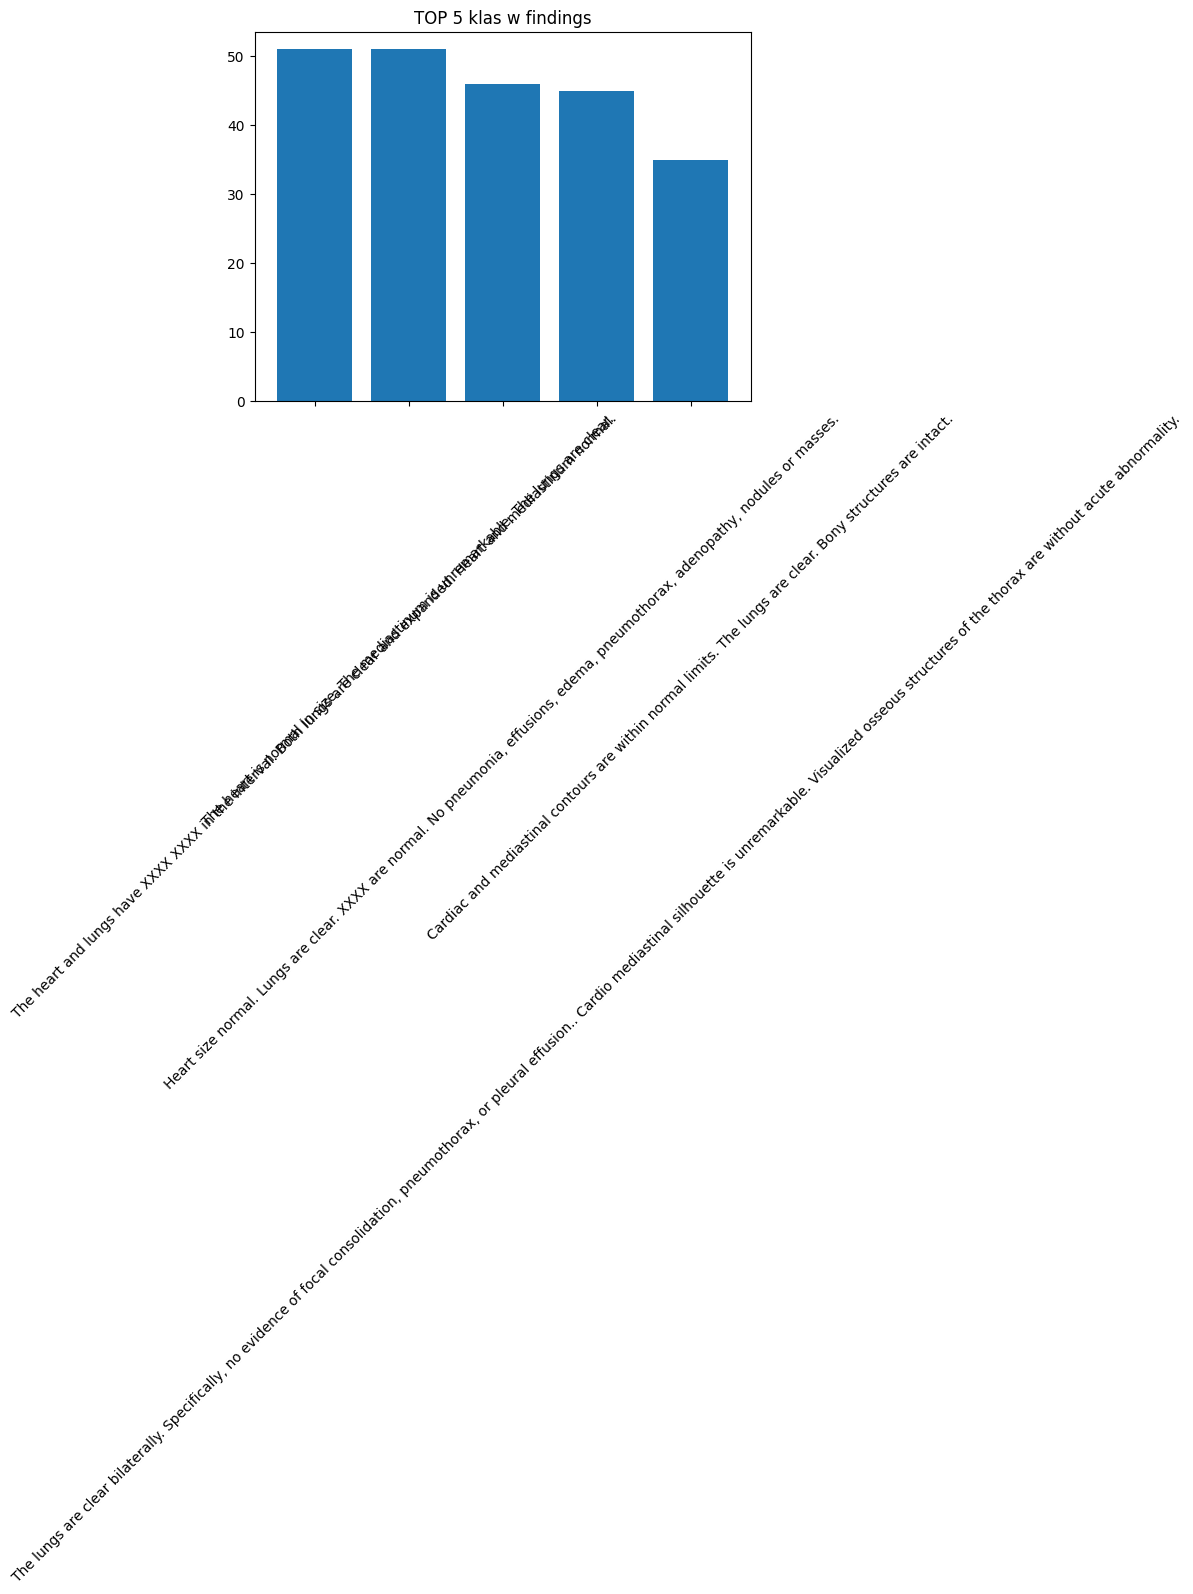

impression: {'No acute cardiopulmonary abnormality.': 301, 'No active disease.': 127, 'No acute cardiopulmonary abnormalities.': 112, 'No acute cardiopulmonary findings.': 111, 'No acute disease.': 109}


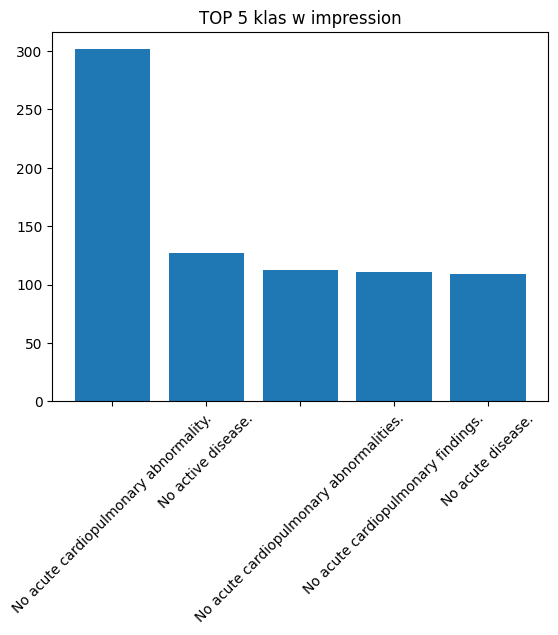

In [77]:
import itertools
for k,v in d.items():
    top_5_items = dict(itertools.islice(v.items(), 5))
    if not top_5_items:
        continue
    print(f"{k}: {top_5_items}")
    plt.figure(dpi=100)
    plt.bar(top_5_items.keys(), top_5_items.values())
    plt.xticks(rotation=45)
    plt.title(f"TOP 5 klas w {k}")
    plt.show()